# Trace of a product, without forming the product

Implementation in [`product_trace.py`](product_trace.py).

`tr(XY)` needs only the diagonal of `XY`, so computing all n^2 entries in order
to sum n of them is wasteful. Splitting both matrices into quadrants gives

    tr(XY) = tr(X0 Y0) + tr(X1 Y2) + tr(X2 Y1) + tr(X3 Y3)

and recursing bottoms out at scalars, for O(n^2) instead of O(n^3).

In [1]:
import numpy as np, time
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (7.5, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "figure.dpi": 110})
from product_trace import trace_of_product, split_quadrants

## Quadrant splitting

In [2]:
example = np.arange(1, 17).reshape(4, 4)
print(example, "\n")
for index, quadrant in enumerate(split_quadrants(example)):
    print(f"quadrant {index}:\n{quadrant}\n")

[[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]
 [13 14 15 16]] 

quadrant 0:
[[1 2]
 [5 6]]

quadrant 1:
[[3 4]
 [7 8]]

quadrant 2:
[[ 9 10]
 [13 14]]

quadrant 3:
[[11 12]
 [15 16]]



## It agrees with the definition

In [3]:
rng = np.random.default_rng(0)
for n in (2, 4, 8, 16, 32):
    x, y = rng.random((n, n)), rng.random((n, n))
    mine = trace_of_product(x, y)
    print(f"n={n:>3}  recursive {mine:>12.6f}   np.trace(x @ y) {np.trace(x @ y):>12.6f}   "
          f"difference {abs(mine - np.trace(x @ y)):.2e}")

n=  2  recursive     0.731140   np.trace(x @ y)     0.731140   difference 0.00e+00
n=  4  recursive     4.422145   np.trace(x @ y)     4.422145   difference 0.00e+00
n=  8  recursive    17.808133   np.trace(x @ y)    17.808133   difference 0.00e+00
n= 16  recursive    66.359559   np.trace(x @ y)    66.359559   difference 0.00e+00
n= 32  recursive   246.739940   np.trace(x @ y)   246.739940   difference 2.84e-14


## Honest timing

`np.sum(x * y.T)` is the same O(n^2) in one line, and it is faster than this
recursion at every size. The recursion is here to show the block identity, not
because it is the quickest route.

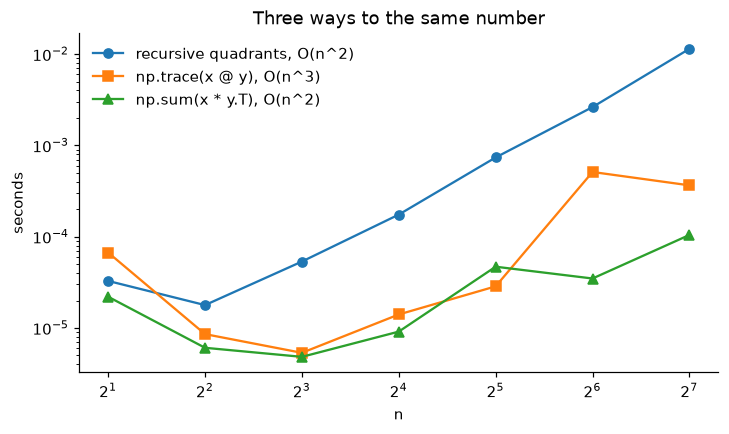

In [4]:
sizes = [2, 4, 8, 16, 32, 64, 128]
recursive, formed, vectorised = [], [], []
for n in sizes:
    x, y = rng.random((n, n)), rng.random((n, n))
    start = time.perf_counter(); trace_of_product(x, y); recursive.append(time.perf_counter() - start)
    start = time.perf_counter(); np.trace(x @ y);        formed.append(time.perf_counter() - start)
    start = time.perf_counter(); np.sum(x * y.T);        vectorised.append(time.perf_counter() - start)

fig, ax = plt.subplots()
ax.plot(sizes, recursive, marker="o", label="recursive quadrants, O(n^2)")
ax.plot(sizes, formed, marker="s", label="np.trace(x @ y), O(n^3)")
ax.plot(sizes, vectorised, marker="^", label="np.sum(x * y.T), O(n^2)")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_xlabel("n"); ax.set_ylabel("seconds"); ax.set_title("Three ways to the same number")
ax.legend(frameon=False); plt.show()

## Sizes it refuses

In [5]:
for bad in (3, 5, 6):
    try:
        trace_of_product(rng.random((bad, bad)), rng.random((bad, bad)))
    except ValueError as error:
        print(f"n={bad}: {error}")

n=3: size must be a power of two, got 3
n=5: size must be a power of two, got 5
n=6: size must be a power of two, got 6
